# Sine-Gordon Solver

## Key Corrections

- The interpolation centers are now selected as grid indices and forced to include the first and last interior points, matching the paper's stated center choice.
- The three-point nonuniform second divided difference is evaluated only at interior center indices.
- The solver now computes `(L_W2 u)''`, not only `L_W2 u`; Eq. (18) requires the second derivative.
- The Wu-Schaback `psi_j''` weights are implemented analytically from Eq. (12).
- The first time level uses the initial velocity and initial acceleration, so the two-step recurrence has a valid start.
- Boundary values are imposed at every time level.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

## Parameters

The defaults below reproduce Example 1 from the paper. Example 1 removes the nonlinear `sin(u)` term and solves the linear wave problem on `[-1, 1]`.


In [60]:
# Correction: use the paper's Example 1 parameters instead of unrelated test values.
a = -1.0
b = 1.0
h = 0.01
tau = 0.01
T = 1.0

# Correction: K must divide n because the paper defines N = n / K.
K = 8

# Shape parameters used in Table 1 for Example 1.
c = 0.027
s = 0.8

# Example 1 omits the nonlinear term sin(u).
include_nonlinear_term = False


## Basis Functions

Eq. (7):

$$\varphi(r) = \frac{s^2}{(s^2 + r^2)^{3/2}}.$$

Eq. (10):

$$\phi_i(x) = \sqrt{c^2 + (x - x_i)^2}.$$


In [ ]:
def imq_second_kernel(r, s):
    """Eq. (7), also the second derivative of sqrt(s^2 + r^2)."""
    r = np.asarray(r, dtype=float)
    return s**2 / (s**2 + r**2)**1.5


def mq_basis(r, c):
    """Multiquadric basis sqrt(c^2 + r^2)."""
    r = np.asarray(r, dtype=float)
    return np.sqrt(c**2 + r**2)


## Grid and Interpolation Centers

The paper uses grid points $x_i = a + i(b-a)/n$, $i = 0, ..., n$, and $N = n/K$ centers selected from interior grid points.


In [62]:
# Correction: build x_i from h and verify that h exactly divides the interval.
def make_uniform_grid(a, b, h):
    n_float = (b - a) / h
    n = int(round(n_float))
    if not np.isclose(n_float, n):
        raise ValueError("h must divide b-a so that the grid has an integer number of subintervals.")
    return np.linspace(a, b, n + 1), n


# Correction: choose N=n/K interior grid indices and force the first and last centers to be x_1 and x_{n-1}.
def select_center_indices(n, K):
    if K <= 0:
        raise ValueError("K must be a positive integer.")
    if n % K != 0:
        raise ValueError("n must be divisible by K because the paper defines N = n / K.")

    N = n // K
    if N < 2:
        raise ValueError("Need at least two centers; choose a smaller K or a finer grid.")

    indices = np.rint(np.linspace(1, n - 1, N)).astype(int)
    indices[0] = 1
    indices[-1] = n - 1

    if np.any(indices <= 0) or np.any(indices >= n):
        raise ValueError("All centers must be strictly interior grid points.")
    if len(np.unique(indices)) != N:
        raise ValueError("Center selection produced duplicate indices; use a finer grid or smaller K.")

    return indices


x, n = make_uniform_grid(a, b, h)
k_idx = select_center_indices(n, K)
xk = x[k_idx]
N = len(k_idx)

print(f"n = {n}, N = {N}")
print("First and last centers:", xk[0], xk[-1])
print("First five center indices:", k_idx[:5])
print("Last five center indices:", k_idx[-5:])


n = 200, N = 25
First and last centers: -0.99 0.99
First five center indices: [ 1  9 18 26 34]
Last five center indices: [166 174 182 191 199]


## Second Divided Difference at Centers

For each selected center $x_{k_j}$, the paper approximates $f''(x_{k_j})$ using the neighboring grid values.


In [ ]:
# Evaluate the divided-difference formula only at interior center indices k_j.
def second_divided_difference_values(x, values, center_indices):
    values = np.asarray(values, dtype=float)
    out = np.empty(len(center_indices), dtype=float)

    for m, k in enumerate(center_indices):
        if k <= 0 or k >= len(x) - 1:
            raise ValueError("Each center index must be strictly interior for the second divided difference.")

        xm, x0, xp = x[k - 1], x[k], x[k + 1]
        fm, f0, fp = values[k - 1], values[k], values[k + 1]

        numerator = 2.0 * ((x0 - xm) * fp - (xp - xm) * f0 + (xp - x0) * fm)
        denominator = (x0 - xm) * (xp - x0) * (xp - xm)
        out[m] = numerator / denominator

    return out


## Wu-Schaback $psi_j''$ Weights

Eq. (18) requires

$$\sum_i e(x_i)\psi_i''(x_k),$$

so we need the second derivatives of the Eq. (12) basis functions. The linear terms in Eq. (12) vanish after two derivatives, and $\phi_i''(x)$ is Eq. (7) with shape parameter `c`.


In [64]:
# Correction: implement psi_j'' analytically; Eq. (18) needs psi_j'', not psi_j.
def psi_second_derivative(eval_points, j, x, c):
    eval_points = np.asarray(eval_points, dtype=float)
    n = len(x) - 1

    phi2 = lambda idx: imq_second_kernel(eval_points - x[idx], c)

    if j == 0:
        return phi2(1) / (2.0 * (x[1] - x[0]))

    if j == 1:
        return ((phi2(2) - phi2(1)) / (2.0 * (x[2] - x[1]))
                - phi2(1) / (2.0 * (x[1] - x[0])))

    if j == n - 1:
        return (-phi2(n - 1) / (2.0 * (x[n] - x[n - 1]))
                - (phi2(n - 1) - phi2(n - 2)) / (2.0 * (x[n - 1] - x[n - 2])))

    if j == n:
        return phi2(n - 1) / (2.0 * (x[n] - x[n - 1]))

    return ((phi2(j + 1) - phi2(j)) / (2.0 * (x[j + 1] - x[j]))
            - (phi2(j) - phi2(j - 1)) / (2.0 * (x[j] - x[j - 1])))


# Correction: precompute the matrix with entries psi_i''(x_k) so every time step uses Eq. (18) directly.
def psi_second_matrix(eval_points, x, c):
    eval_points = np.asarray(eval_points, dtype=float)
    matrix = np.empty((len(eval_points), len(x)), dtype=float)
    for j in range(len(x)):
        matrix[:, j] = psi_second_derivative(eval_points, j, x, c)
    return matrix


## Precomputation for $L_{W_{2}} f''$

Eq. (15) solves $A \alpha = f''(x_{k_j})$, and Eq. (17) gives $L_{W_{2}}$. Differentiating Eq. (17) twice gives the spatial derivative used in Eq. (18).


In [65]:
# Correction: construct the RBF interpolation matrix A_ij = varphi(|x_{k_i} - x_{k_j}|, s).
def rbf_matrix(xk, s):
    distances = np.abs(xk[:, None] - xk[None, :])
    return imq_second_kernel(distances, s)


# Correction: keep all reusable matrices together; A and psi_i'' do not change during time stepping.
def precompute_lw2_second_derivative(x, center_indices, s, c):
    xk = x[center_indices]
    A = rbf_matrix(xk, s)

    return {
        "x": x,
        "center_indices": center_indices,
        "xk": xk,
        "A": A,
        "rbf_second_on_grid": imq_second_kernel(x[:, None] - xk[None, :], s),
        "mq_on_grid": mq_basis(x[:, None] - xk[None, :], s),
        "psi_second_on_grid": psi_second_matrix(x, x, c),
    }


# Correction: this is the actual quantity used in Eq. (18): (L_W2 f)'' evaluated on the grid.
def lw2_second_derivative(values, operators):
    x = operators["x"]
    center_indices = operators["center_indices"]
    A = operators["A"]

    rhs = second_divided_difference_values(x, values, center_indices)

    # Correction: solve A alpha = rhs; do not use an elementwise inverse or a shortcut formula.
    alpha = np.linalg.solve(A, rhs)

    rbf_part = operators["rbf_second_on_grid"] @ alpha
    residual_values = np.asarray(values, dtype=float) - operators["mq_on_grid"] @ alpha
    ld_part = operators["psi_second_on_grid"] @ residual_values

    return rbf_part + ld_part, alpha


operators = precompute_lw2_second_derivative(x, k_idx, s, c)
print("A shape:", operators["A"].shape)
print("psi_second matrix shape:", operators["psi_second_on_grid"].shape)


A shape: (25, 25)
psi_second matrix shape: (201, 201)


## Sine-Gordon Time Stepping

Eq. (18):

$$u_k^{n+1} = 2u_k^n - u_k^{n-1} - \tau^2\sin(u_k^n) + \tau^2(L_{W_2}u^n)''(x_k).$$

For Example 1, set `include_nonlinear_term=False` because the paper removes `sin(u)`.


In [66]:
# Correction: initialize u^1 using u_t(x,0)=g(x) and the initial acceleration.
def first_time_level(u0, velocity0, tau, operators, include_nonlinear_term):
    uxx0, _ = lw2_second_derivative(u0, operators)
    nonlinear0 = np.sin(u0) if include_nonlinear_term else 0.0
    return u0 + tau * velocity0 + 0.5 * tau**2 * (uxx0 - nonlinear0)


# Correction: impose Dirichlet boundary conditions after every update, as required by Eq. (4).
def apply_boundary_values(u, t, left_boundary, right_boundary):
    u = np.asarray(u, dtype=float).copy()
    u[0] = left_boundary(t)
    u[-1] = right_boundary(t)
    return u


# Correction: use Eq. (18) with (L_W2 u)'' at each time step.
def solve_sine_gordon(a, b, h, tau, T, K, s, c,
                      initial_displacement, initial_velocity,
                      left_boundary, right_boundary,
                      include_nonlinear_term=True):
    x, n = make_uniform_grid(a, b, h)
    nt_float = T / tau
    nt = int(round(nt_float))
    if not np.isclose(nt_float, nt):
        raise ValueError("T must be an integer multiple of tau.")

    center_indices = select_center_indices(n, K)
    operators = precompute_lw2_second_derivative(x, center_indices, s, c)

    u_prev = apply_boundary_values(initial_displacement(x), 0.0, left_boundary, right_boundary)
    velocity0 = initial_velocity(x)

    if nt == 0:
        return x, u_prev, operators

    u_curr = first_time_level(u_prev, velocity0, tau, operators, include_nonlinear_term)
    u_curr = apply_boundary_values(u_curr, tau, left_boundary, right_boundary)

    for step in range(1, nt):
        t_next = (step + 1) * tau
        uxx, _ = lw2_second_derivative(u_curr, operators)
        nonlinear = np.sin(u_curr) if include_nonlinear_term else 0.0

        u_next = 2.0 * u_curr - u_prev + tau**2 * (uxx - nonlinear)
        u_next = apply_boundary_values(u_next, t_next, left_boundary, right_boundary)

        u_prev, u_curr = u_curr, u_next

    return x, u_curr, operators


## Error Metrics

The paper defines `RMS = (1/(n+1)) sqrt(sum(error_i^2))`, which is different from the common `sqrt(mean(error_i^2))`. Both are shown below to avoid confusion.


In [67]:
# Correction: keep the paper's RMS definition separate from the standard RMS definition.
def linf_error(numerical, exact):
    return np.max(np.abs(np.asarray(exact) - np.asarray(numerical)))


def paper_rms_error(numerical, exact):
    error = np.asarray(exact) - np.asarray(numerical)
    return np.sqrt(np.sum(error**2)) / len(error)


def standard_rms_error(numerical, exact):
    error = np.asarray(exact) - np.asarray(numerical)
    return np.sqrt(np.mean(error**2))


## Example 1 From the Paper

Initial and boundary data:

$$u(x,0)=\sin(\pi x), \qquad u_t(x,0)=0, \qquad u(-1,t)=u(1,t)=0.$$

Exact solution:

$$u(x,t)=\sin(\pi x)\cos(\pi t).$$


In [68]:
# Correction: define Example 1 exactly as stated in the paper.
def example1_initial_displacement(x):
    return np.sin(np.pi * x)


def example1_initial_velocity(x):
    return np.zeros_like(x)


def example1_left_boundary(t):
    return 0.0


def example1_right_boundary(t):
    return 0.0


def example1_exact_solution(x, t):
    return np.sin(np.pi * x) * np.cos(np.pi * t)


In [69]:
start = time.perf_counter()
x_num, u_num, operators = solve_sine_gordon(
    a=a,
    b=b,
    h=h,
    tau=tau,
    T=T,
    K=K,
    s=s,
    c=c,
    initial_displacement=example1_initial_displacement,
    initial_velocity=example1_initial_velocity,
    left_boundary=example1_left_boundary,
    right_boundary=example1_right_boundary,
    include_nonlinear_term=include_nonlinear_term,
)
elapsed = time.perf_counter() - start

u_exact = example1_exact_solution(x_num, T)

print("L_inf error:", linf_error(u_num, u_exact))
print("Paper RMS error:", paper_rms_error(u_num, u_exact))
print("Standard RMS error:", standard_rms_error(u_num, u_exact))
print("Elapsed seconds:", elapsed)


L_inf error: 7.607721928515332e-05
Paper RMS error: 1.4564364067918685e-06
Standard RMS error: 2.0648549789580642e-05
Elapsed seconds: 0.015151646977756172


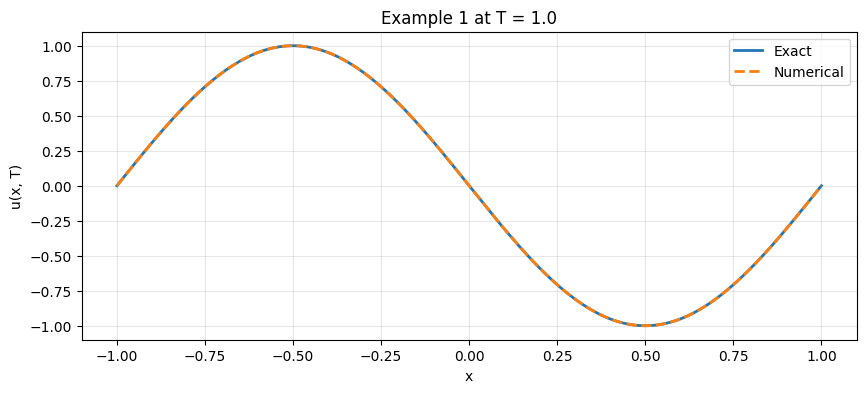

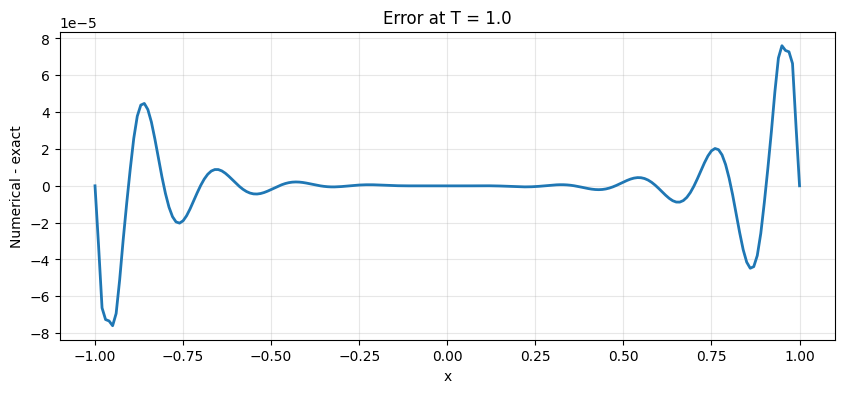

In [70]:
# Correction: plot only when matplotlib is available; the numerical solver does not depend on plotting.
if plt is None:
    print("matplotlib is not installed; skipping plots.")
else:
    plt.figure(figsize=(10, 4))
    plt.plot(x_num, u_exact, label="Exact", linewidth=2)
    plt.plot(x_num, u_num, "--", label="Numerical", linewidth=2)
    plt.xlabel("x")
    plt.ylabel("u(x, T)")
    plt.title(f"Example 1 at T = {T}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(x_num, u_num - u_exact, linewidth=2)
    plt.xlabel("x")
    plt.ylabel("Numerical - exact")
    plt.title(f"Error at T = {T}")
    plt.grid(True, alpha=0.3)
    plt.show()


## Example 2 Setup

Use this cell to run the nonlinear example from the paper:

$$u(x,0)=0, \qquad u_t(x,0)=4\operatorname{sech}(x), \qquad u(x,t)=4\arctan(t\operatorname{sech}(x)).$$


In [71]:
# Correction: Example 2 keeps the nonlinear sin(u) term and uses boundary values from the exact solution.
def sech(x):
    return 1.0 / np.cosh(x)


def example2_initial_displacement(x):
    return np.zeros_like(x)


def example2_initial_velocity(x):
    return 4.0 * sech(x)


def example2_exact_solution(x, t):
    return 4.0 * np.arctan(t * sech(x))


def run_example2(T2=1.0):
    a2, b2 = -2.0, 2.0
    h2 = 0.01
    tau2 = 0.01
    K2 = 10
    s2 = 1.0
    c2 = 0.1 * np.cbrt(h2)

    left = lambda t: example2_exact_solution(np.array([a2]), t)[0]
    right = lambda t: example2_exact_solution(np.array([b2]), t)[0]

    x2, u2, _ = solve_sine_gordon(
        a=a2,
        b=b2,
        h=h2,
        tau=tau2,
        T=T2,
        K=K2,
        s=s2,
        c=c2,
        initial_displacement=example2_initial_displacement,
        initial_velocity=example2_initial_velocity,
        left_boundary=left,
        right_boundary=right,
        include_nonlinear_term=True,
    )

    exact2 = example2_exact_solution(x2, T2)
    return x2, u2, exact2


# Uncomment to run Example 2.
# x2, u2, exact2 = run_example2(T2=1.0)
# print("Example 2 L_inf error:", linf_error(u2, exact2))
# print("Example 2 paper RMS error:", paper_rms_error(u2, exact2))
